# Mol3D Experiment — Results Analysis

Compares CT (coords / simple / full), GNN (GCN / GAT / GIN), and SchNet on the Mol3D dataset.
Task: molecular property regression (single target).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR = Path('results')

In [2]:
FILES = {
    'CT-coords': 'results_mol3d_ct_coords.json',
    'CT-simple': 'results_mol3d_ct_simple.json',
    'CT-full':   'results_mol3d_ct_full.json',
    'GCN':       'results_mol3d_gcn.json',
    'GAT':       'results_mol3d_gat.json',
    'GIN':       'results_mol3d_gin.json',
    'SchNet':    'results_mol3d_schnet.json',
}

data = {}
for label, fname in FILES.items():
    p = RESULTS_DIR / fname
    if p.exists():
        with open(p) as f:
            data[label] = json.load(f)
    else:
        print(f'Missing: {fname}')

print(f'Loaded {len(data)} result files: {list(data.keys())}')

Loaded 7 result files: ['CT-coords', 'CT-simple', 'CT-full', 'GCN', 'GAT', 'GIN', 'SchNet']


## Summary Table

In [3]:
rows = []
for label, d in data.items():
    run_rmses = [r['test_rmse'] for r in d['runs']]
    run_maes  = [r['test_mae']  for r in d['runs']]
    run_r2s   = [r['test_r2']   for r in d['runs']]
    rows.append({
        'model':      label,
        'num_params': d.get('num_params'),
        'RMSE':       d['mean_test_rmse'],
        'RMSE_std':   round(float(np.std(run_rmses)), 4),
        'MAE':        d['mean_test_mae'],
        'MAE_std':    round(float(np.std(run_maes)),  4),
        'R²':         d['mean_test_r2'],
        'R²_std':     round(float(np.std(run_r2s)),   4),
    })

df = pd.DataFrame(rows).set_index('model')
df.sort_values('RMSE', inplace=True)
display(df.style
        .format(precision=4)
        .background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r', axis=0)
        .background_gradient(subset=['R²'],          cmap='RdYlGn',   axis=0))

,num_params,RMSE,RMSE_std,MAE,MAE_std,R²,R²_std
model,,,,,,,
CT-full,2163201,0.4408,0.0181,0.2959,0.0108,0.8517,0.0122
SchNet,1714433,0.4766,0.0061,0.3203,0.0035,0.8270,0.0044
GAT,297665,0.5420,0.0134,0.3779,0.0092,0.7761,0.0111
GIN,29956,0.6617,0.0146,0.4713,0.0074,0.6663,0.0146
CT-simple,2158721,0.6901,0.0021,0.4860,0.0042,0.6372,0.0021
GCN,17473,0.7155,0.0103,0.5144,0.0069,0.6099,0.0112
CT-coords,2159233,0.8281,0.0250,0.6227,0.0197,0.4772,0.0313


## Metric Comparison — Bar Charts

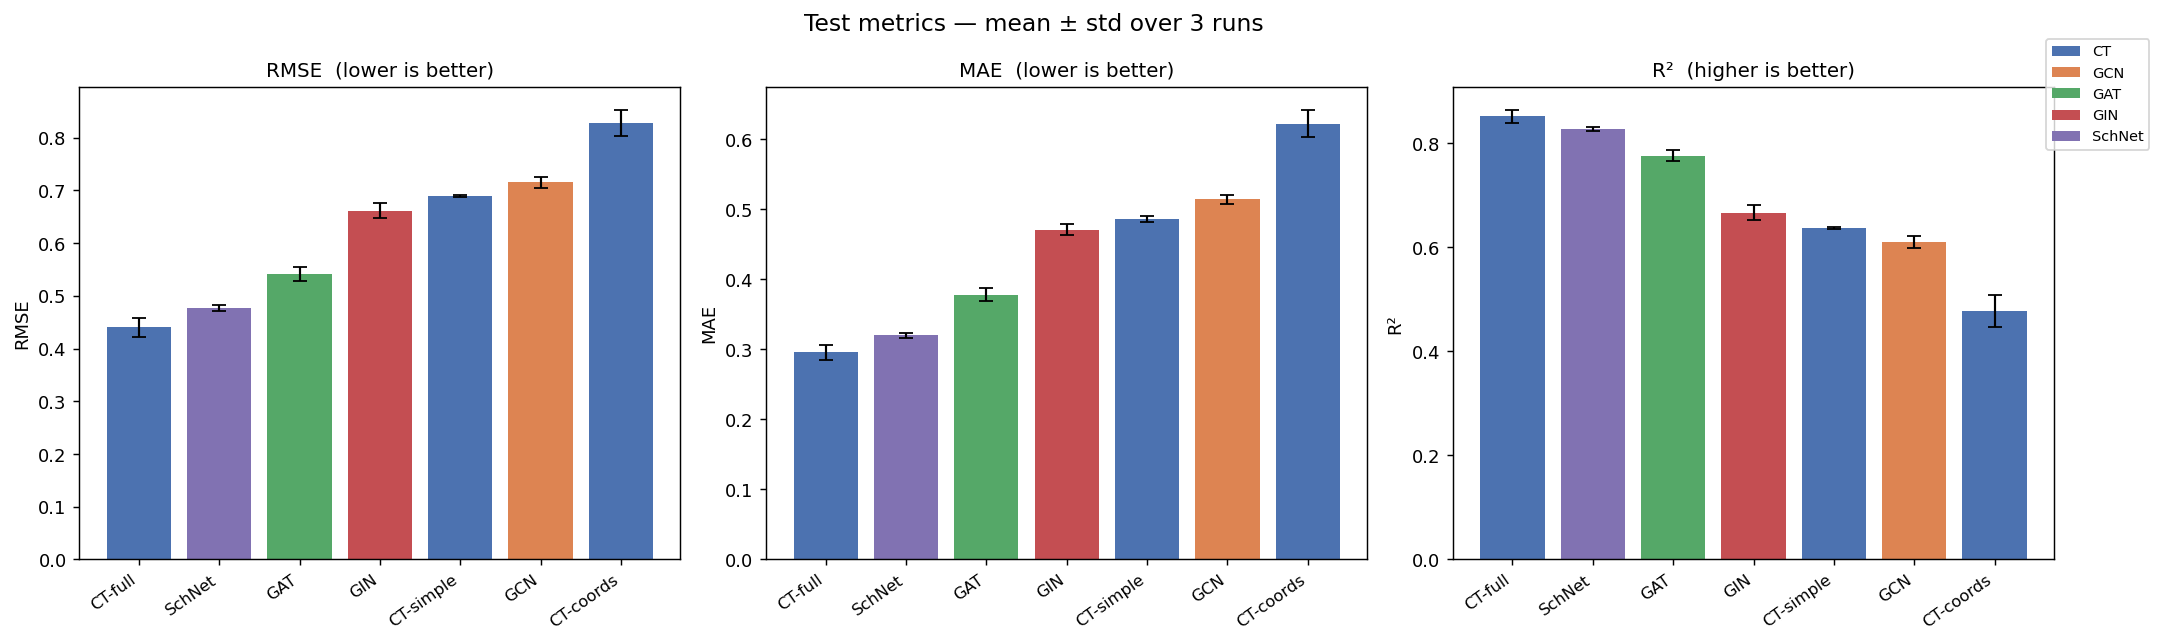

In [4]:
COLORS = {
    'CT':     '#4C72B0',
    'GCN':    '#DD8452',
    'GAT':    '#55A868',
    'GIN':    '#C44E52',
    'SchNet': '#8172B2',
}

def model_color(label):
    for prefix, c in COLORS.items():
        if label.startswith(prefix):
            return c
    return 'gray'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, col, cmap_dir) in zip(axes, [
        ('RMSE', 'RMSE', 'lower'), ('MAE', 'MAE', 'lower'), ('R²', 'R²', 'higher')]):
    vals   = df[col].dropna()
    stds   = df.loc[vals.index, f'{col}_std']
    colors = [model_color(m) for m in vals.index]
    ax.bar(range(len(vals)), vals.values, color=colors,
           yerr=stds.values, capsize=4, error_kw={'linewidth': 1.2})
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=9)
    ax.set_title(f'{metric}  ({cmap_dir} is better)', fontsize=11)
    ax.set_ylabel(metric)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=k) for k, c in COLORS.items()]
fig.legend(handles=legend_elements, loc='upper right', fontsize=8,
           bbox_to_anchor=(1.04, 0.95))
plt.suptitle('Test metrics — mean ± std over 3 runs', fontsize=13)
plt.tight_layout()
plt.show()

## Training Loss Curves

/var/folders/lz/xk74mjz162n7c2k2y1p9ts8c0000gn/T/ipykernel_7576/1925164123.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', max(len(models), 1))


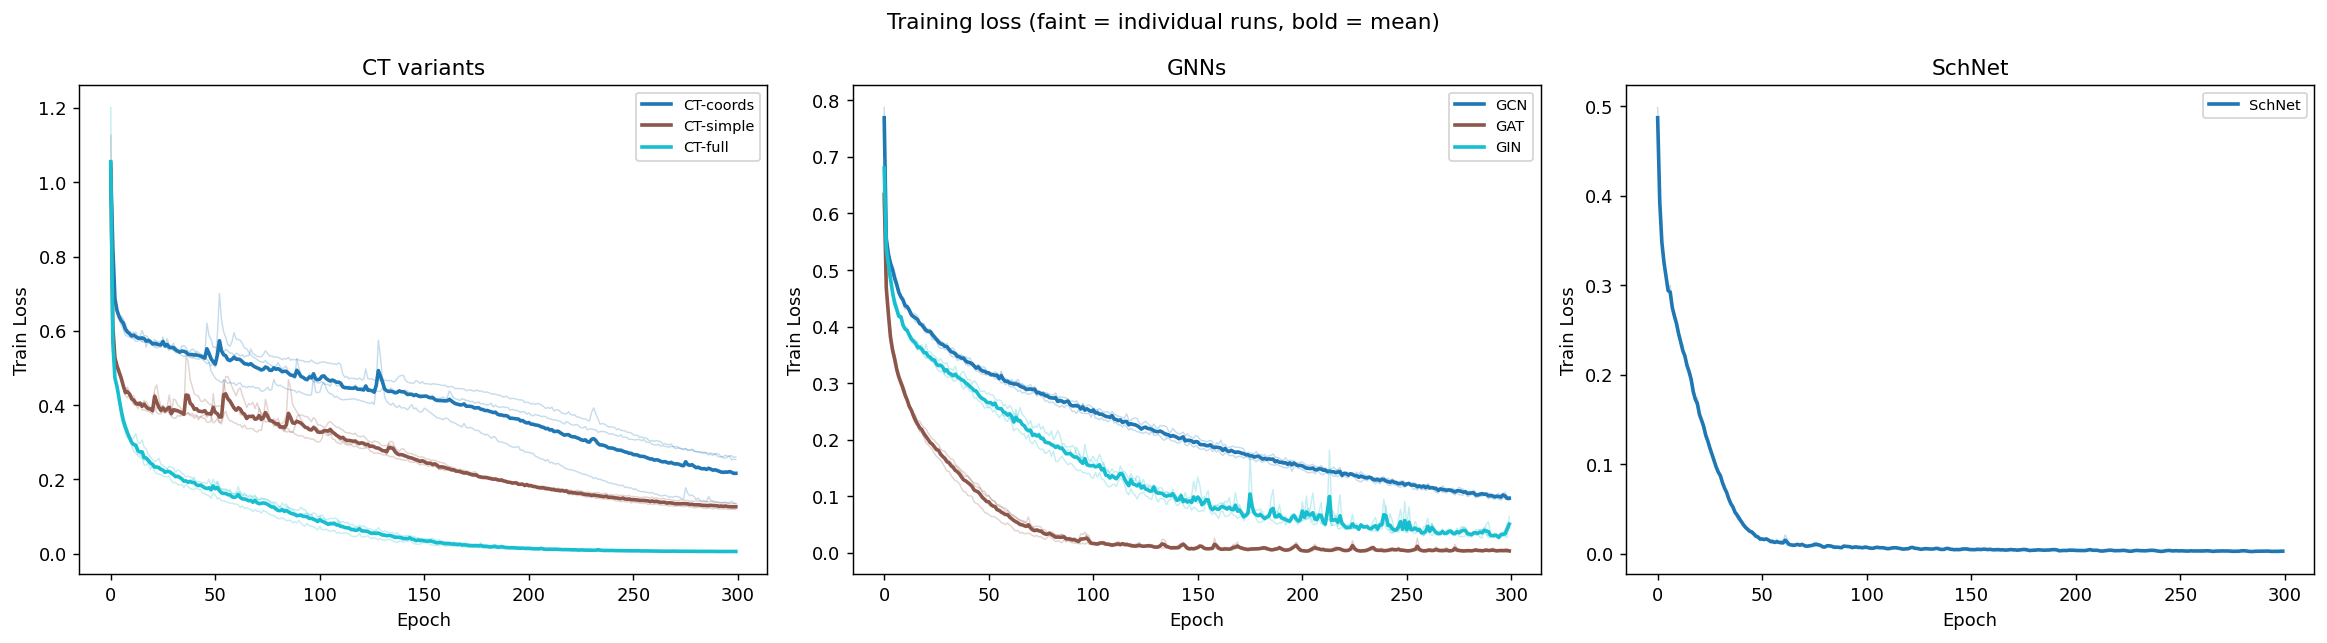

In [5]:
GROUPS = {
    'CT variants':   [k for k in data if k.startswith('CT')],
    'GNNs':          [k for k in data if k in ('GCN', 'GAT', 'GIN')],
    'SchNet':        [k for k in data if k == 'SchNet'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (group_name, models) in zip(axes, GROUPS.items()):
    cmap = cm.get_cmap('tab10', max(len(models), 1))
    for idx, label in enumerate(models):
        if label not in data:
            continue
        d = data[label]
        all_losses = [r['train_losses'] for r in d['runs']]
        min_len = min(len(l) for l in all_losses)
        mean_losses = np.mean([l[:min_len] for l in all_losses], axis=0)
        color = cmap(idx)
        for l in all_losses:
            ax.plot(l[:min_len], color=color, alpha=0.25, linewidth=0.8)
        ax.plot(mean_losses, color=color, linewidth=2, label=label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title(group_name)
    ax.legend(fontsize=8)

plt.suptitle('Training loss (faint = individual runs, bold = mean)', fontsize=12)
plt.tight_layout()
plt.show()

## Predicted vs. True (Run 1)

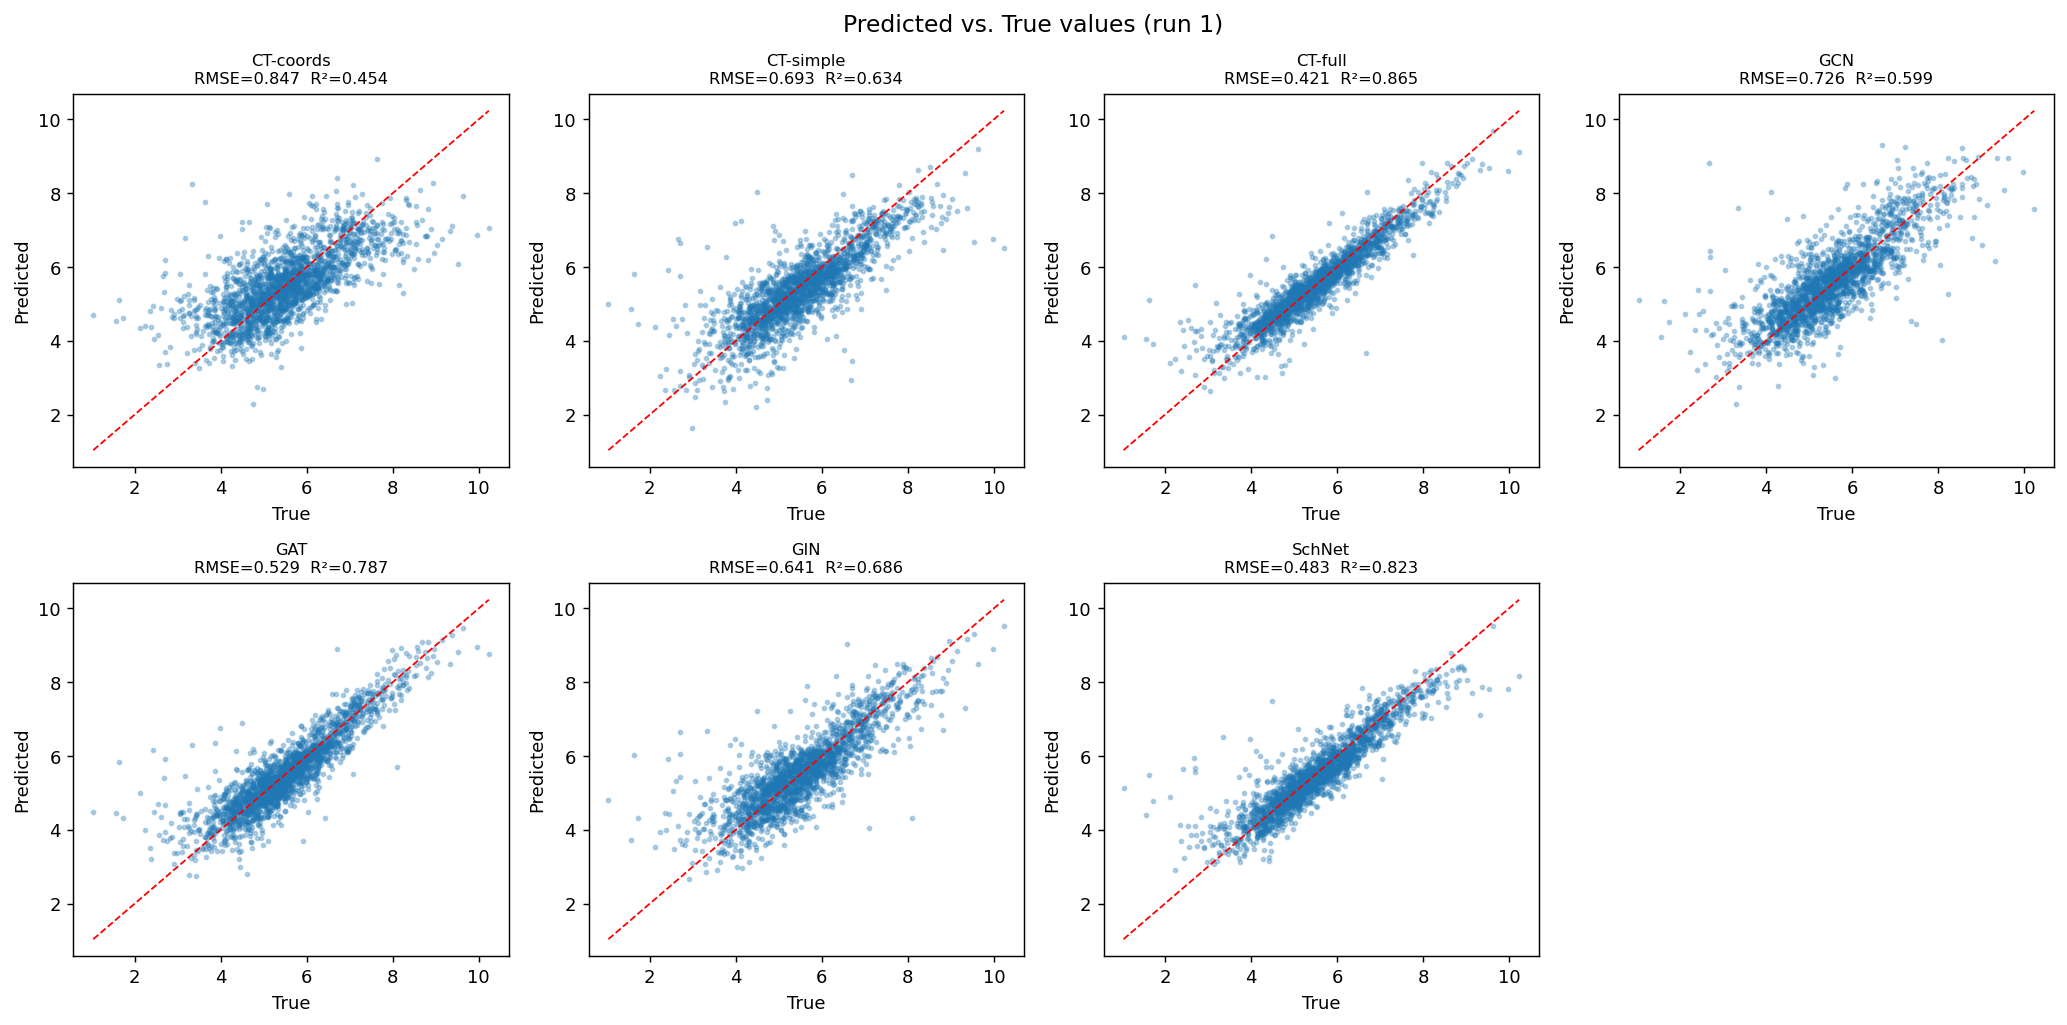

In [6]:
n_models = len(data)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for ax, (label, d) in zip(axes, data.items()):
    preds = d['runs'][0].get('predictions', [])
    if not preds:
        ax.set_visible(False)
        continue
    true_vals = np.array([p['true'] for p in preds])
    pred_vals = np.array([p['pred'] for p in preds])
    vmin, vmax = true_vals.min(), true_vals.max()
    ax.scatter(true_vals, pred_vals, alpha=0.3, s=5, rasterized=True)
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1)
    rmse = d['runs'][0]['test_rmse']
    r2   = d['runs'][0]['test_r2']
    ax.set_title(f'{label}\nRMSE={rmse:.3f}  R²={r2:.3f}', fontsize=9)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')

for ax in axes[len(data):]:
    ax.set_visible(False)

plt.suptitle('Predicted vs. True values (run 1)', fontsize=13)
plt.tight_layout()
plt.show()

## Error Distribution (Run 1)

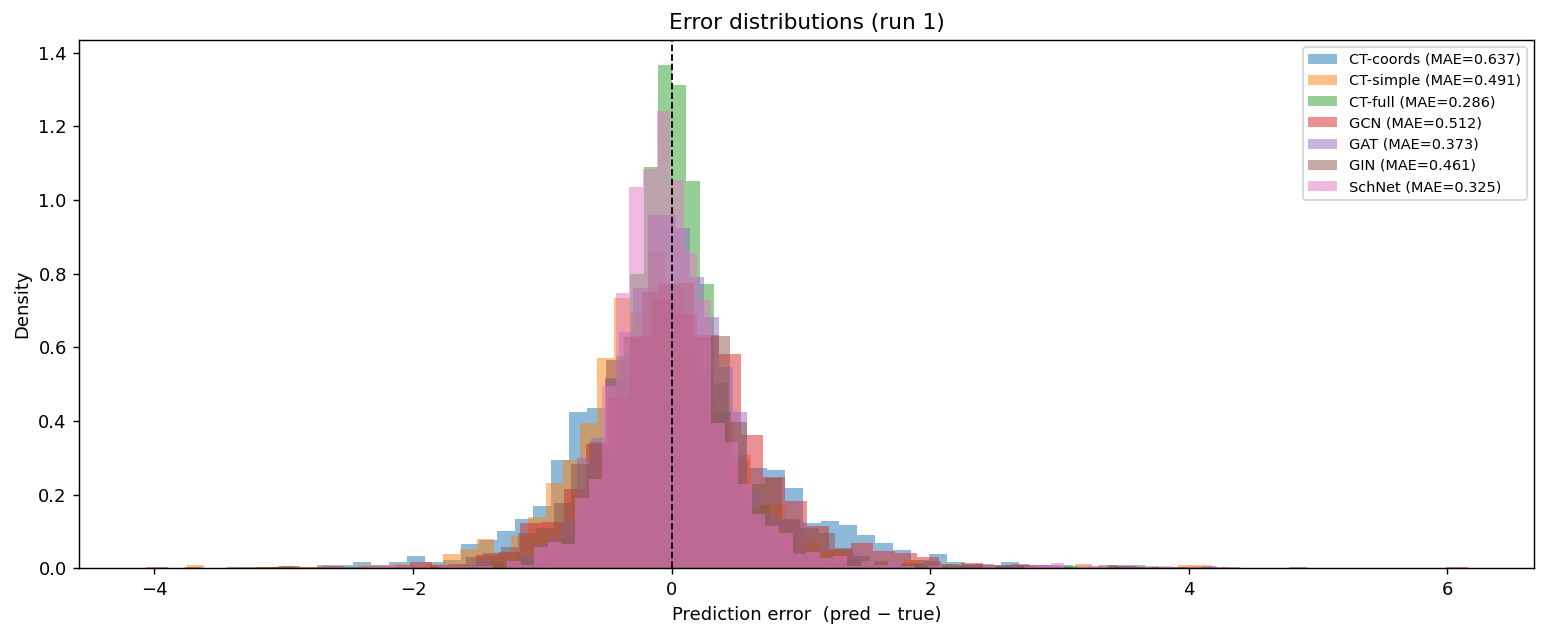

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, d in data.items():
    preds = d['runs'][0].get('predictions', [])
    if not preds:
        continue
    errors = np.array([p['pred'] - p['true'] for p in preds])
    ax.hist(errors, bins=60, alpha=0.5, label=f'{label} (MAE={np.abs(errors).mean():.3f})',
            density=True, histtype='stepfilled')

ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Prediction error  (pred − true)')
ax.set_ylabel('Density')
ax.set_title('Error distributions (run 1)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Runtime & Parameter Count

In [8]:
rt_rows = []
for label, d in data.items():
    runtimes = [r.get('runtime') for r in d['runs'] if r.get('runtime')]
    rt_rows.append({
        'model':          label,
        'num_params':     d.get('num_params'),
        'total_runtime_h': round(sum(runtimes) / 3600, 2) if runtimes else None,
        'per_run_h':       round(np.mean(runtimes) / 3600, 2) if runtimes else None,
    })

rt_df = pd.DataFrame(rt_rows).set_index('model').sort_values('per_run_h')
display(rt_df)

,num_params,total_runtime_h,per_run_h
model,,,
GIN,29956,0.1800,0.0600
GCN,17473,0.2100,0.0700
GAT,297665,0.3300,0.1100
SchNet,1714433,11.7100,3.9000
CT-coords,2159233,15.6500,5.2200
CT-simple,2158721,15.6800,5.2300
CT-full,2163201,15.8600,5.2900


## MAE Table (for slides)

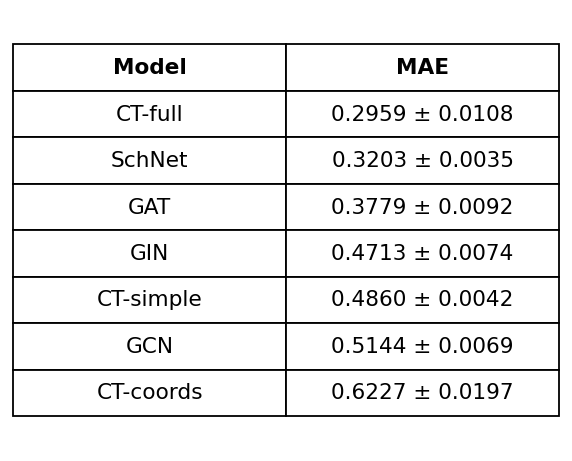

In [10]:
mae_df = df[['MAE', 'MAE_std']].sort_values('MAE').reset_index()

fig, ax = plt.subplots(figsize=(4.5, 0.5 + 0.45 * len(mae_df)))
ax.axis('off')

table = ax.table(
    cellText=[[m, f'{mae:.4f} ± {std:.4f}'] for m, mae, std in mae_df.values],
    colLabels=['Model', 'MAE'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    if row == 0:
        cell.set_text_props(weight='bold')

plt.tight_layout()
plt.savefig('mae_table.jpg', dpi=300, bbox_inches='tight')
plt.show()

## Model Feature Overview (for slides)

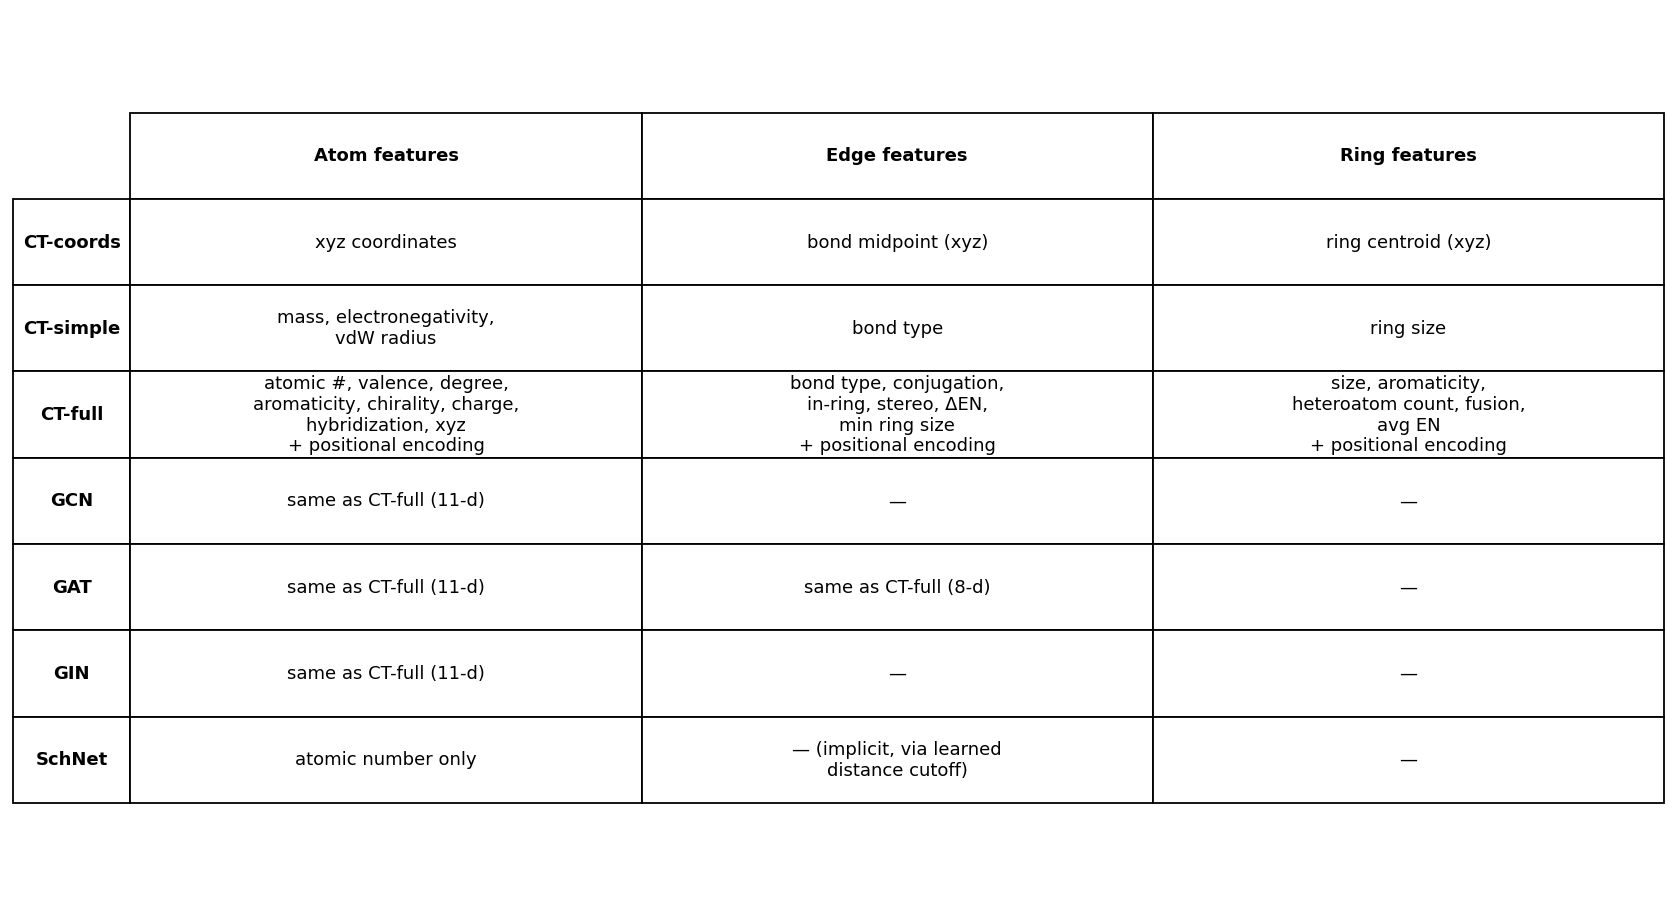

In [11]:
FEATURE_OVERVIEW = [
    ('CT-coords', 'xyz coordinates',
                  'bond midpoint (xyz)',
                  'ring centroid (xyz)'),
    ('CT-simple', 'mass, electronegativity,\nvdW radius',
                  'bond type',
                  'ring size'),
    ('CT-full',   'atomic #, valence, degree,\naromaticity, chirality, charge,\nhybridization, xyz\n+ positional encoding',
                  'bond type, conjugation,\nin-ring, stereo, ΔEN,\nmin ring size\n+ positional encoding',
                  'size, aromaticity,\nheteroatom count, fusion,\navg EN\n+ positional encoding'),
    ('GCN',       'same as CT-full (11-d)', '—', '—'),
    ('GAT',       'same as CT-full (11-d)', 'same as CT-full (8-d)', '—'),
    ('GIN',       'same as CT-full (11-d)', '—', '—'),
    ('SchNet',    'atomic number only', '— (implicit, via learned\ndistance cutoff)', '—'),
]

fig, ax = plt.subplots(figsize=(13, 0.5 + 0.95 * len(FEATURE_OVERVIEW)))
ax.axis('off')

table = ax.table(
    cellText=[list(row[1:]) for row in FEATURE_OVERVIEW],
    rowLabels=[row[0] for row in FEATURE_OVERVIEW],
    colLabels=['Atom features', 'Edge features', 'Ring features'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_text_props(ha='center', va='center')
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold', ha='center', va='center')

plt.tight_layout()
plt.savefig('feature_table.jpg', dpi=300, bbox_inches='tight')
plt.show()